# **ΤΕΛΙΚΗ ΕΡΓΑΣΙΑ**

Φοιτητής: Ιατρού Κωνσταντίνος 58071

Καθηγητής: Θεοδωρακόπουλος Ηλίας

# ΜΕΡΟΣ 2: **Πρόβλεψη πρόσδεσης χημικών μορίων σε βιολογικούς υποδοχείς**

**Στο δεύτερο μέρος καλείστε να επιλύσετε ένα πρόβλημα πρόβλεψης του βαθμού πρόσδεσης (binding) χημικών μορίων σε βιολογικούς υποδοχείς. Η διαδικασία αυτή χρησιμοποιείται συχνά στη φαρμακολογία και τη βιοχημεία για την ανακάλυψη χημικών μορίων που δυνητικά μπορούν να αποτελέσουν ενεργές ουσίες που προσδένονται σε κάποιο υποδοχέα-στόχο και αναστέλλουν τη δράση του. Στο αρχείο Data_Receptors.zip θα βρείτε δεδομένα εκπαίδευσης και δοκιμής για 1115 και 124 χημικά μόρια αντίστοιχα, για καθένα από τα οποία έχουν υπολογισθεί 3473 χαρακτηριστικά. Τα πρώτα 1425 χαρακτηριστικά (κατά στήλες) μπορούν να λάβουν συνεχείς τιμές, ενώ τα 2048 επόμενα αποτελούν binary περιγραφείς των μορίων. Για τα δεδομένα εκπαίδευσης σας δίνονται και οι ετικέτες που καθορίζουν εάν το κάθε μόριο μπορεί να προσδεθεί αποτελεσματικά στον υποδοχέα στόχο (label 1) ή όχι (label 0).**

**a. Σχεδιάστε και υλοποιήστε ένα μοντέλο μηχανικής μάθησης χρησιμοποιώντας κατάλληλους αλγορίθμους της επιλογής σας, συμβατικούς ή/και νευρωνικούς, που δέχεται σαν είσοδο τα χαρακτηριστικά νέων χημικών μορίων και προβλέπει αν το κάθε μόριο μπορεί να συνδεθεί στον υποδοχέα στόχο. Δικαιολογήστε το σκεπτικό σας.**

**b. Τα διαθέσιμα δεδομένα για βελτιστοποίηση και εκπαίδευση του μοντέλου σας είναι μονάχα αυτά που περιλαμβάνονται στο αρχείο Train_features.csv για τα οποία έχετε διαθέσιμες ετικέτες (Train_labels.csv). Ακολουθήστε το κατάλληλο πρωτόκολλο ώστε να βελτιστοποιήσετε τις παραμέτρους του μοντέλου σας, και να εκτιμήσετε με τον καλύτερο δυνατό τρόπο το πιθανό σφάλμα στο test set.**

**c. Δώστε την εκτίμησή σας για το σφάλμα που θα έχει το εκπαιδευμένο μοντέλο σας στο test set, δεδομένου ότι η κατανομή κλάσεων στο test set είναι παρόμοια με αυτή των δεδομένων εκπαίδευσης. Να εκτιμήσετε επίσης το AUC για την καμπύλη TP-FP. Τέλος, να παράξετε ένα αρχείο με όνομα test_predictions.csv στο οποίο θα καταχωρήσετε την πρόβλεψη του μοντέλου σας για κάθε δείγμα από το test set στη μορφή predicted_label,prediction_score σε κάθε γραμμή, με τη σειρά που περιέχονται τα δεδομένα στο test_features.csv. Το prediction_score αποτελεί την πρωτογενή έξοδο του ταξινομητή σας και πρέπει να είναι είτε η πιθανότητα πρόσδεσης είτε να έχει αύξουσα τιμή για αυξανόμενη πιθανότητα πρόσδεσης. Το αρχείο να συμπεριληφθεί μαζί με τα υπόλοιπα παραδοτέα της εργασίας στην υποβολή σας.**



In [7]:
# Εισαγωγή απαραίτητων βιβλιοθηκών, συναρτήσεων και κλάσεων
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc, precision_recall_curve, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

!pip install optuna
import optuna

Εδώ εισάγονται οι βιβλιοθήκες, οι κλάσεις και οι συναρτήσεις που θα χρειαστούν για την συνέχεια της άσκησης:

1. Η βιβλιοθήκη numpy, που περιέχει συναρτήσεις για να γίνονται αποδοτικά πράξεις με πίνακες.
2. Η βιβλιοθήκη pandas, η οποια προσφέρει ευκολότερη διαχείριση και ανάλυση δεδομένων, μέσω των δομων DataFrames. Ακόμη επιτρέπει εύκολη εισαγωγή και εξαγωγή δεδομένων από και πρός αρχεία τύπου csv.
3. Το module pyplot της βιβλιοθήκης matplotlib δίνει την δυνατότητα δημιουργίας απεικονήσεων πιο κατανοητών για εμας και διαγραμματων
4. Η κλαση StandardScaler δίνει την δυνατότητα δημιουργίας αντικειμένων τέτοιου τύπου που εφαρμόζουν κανονικοποίηση στα δεδομένα.
5. Η κλάση PCA δημιουργεί αντικείμενα που μπορούν να εφαρμόσουν την μέθοδο Ανάλυσης σε Κύριες Συνιστώσες (PCA) για την μείωση των διαστάσεων του προβλήματος με την ελάχιστη δυνατή απώλεια διασποράς
6. Η κλάση LinearDiscriminantAnalysis δημιουργει αντικείμενα που μπορούν να εφαρμόσουν την μέθοδο μείωσης διαστάσεων LDA.
7. Η συνάρτηση train_test_split μπορεί να διαχωρίσει το σετ δεδομένων σε 2 μικρότερα ανεξάρτητα μεταξύ τους σετ δεδομένων.
8. Η συνάρτηση υπολογίζει το σωστό ποσοστό των προβλέψεων του ταξινομητή συγκρίνοντας τις προβλέψεις με τις πραγματικές ετικέτες.
9. Η roc_curve και η auc χρησιμοποιούνται για την αξιολόγηση της απόδοσης ενός ταξινομητή υλοποιώντας την καμπύλη ROC και υπολογίζοντας το εμβαδόν από κάτω της (AUC). Η συνάρτηση precision_recall_curve υπολογίζει τις λίστες για την δημιουργία της καμπύλης precision-recall.
10. Η βιβλιοθήκη pytorch δίνει εργαλεία για την δημιουργία δομών τύπου tensors και την εκπαίδευση νευρωνικών δικτύων
11. Το module nn της pytorch δίνει δομές που μας βοηθάνε στην δημιουργία μοντέλων νευρωνικών δικτύων.
12. Το module optim της pytorch παρέχει συναρτήσεις που υλοποιούν αλγορίθμους βελτιστοποίησης.
13. Οι κλάσεις TensorDataset και DataLoader χρησιμοποιούνται για την φορτωση δεδομένων στο νευρωνικό δίκτυο ώστε να γίνει η εκπαίδευση του.
14. Η βιβλιοθήκη optuna παρέχει συναρτήσεις που βοηθάνε στην βελτιστοποίηση των παραμέτρων σε μοντέλα μηχανικής μάθησησης.

In [8]:
# Εισαγωγή σετ δεδομένων
data_file = 'Train_Features.csv'
labels_file = 'Train_Labels.csv'
unlabeled_test_data_file = 'Test_Features.csv'

data = pd.read_csv(data_file, header=None)
labels = pd.read_csv(labels_file, header=None)
unlabeled_test_data = pd.read_csv(unlabeled_test_data_file, header=None)

Εδώ εισάγονται τα δεδομένα εκπαίδευσης με τις ετικέτες τους και τα δεδομένα του test set για τα οποία δεν έχουμε ετικέτες.

In [9]:
data_train, data_validation, labels_train, labels_validation = train_test_split(data, labels, test_size=0.15, stratify=labels, random_state=123)
data_validation, data_test, labels_validation, labels_test = train_test_split(data_validation, labels_validation, test_size=(168-124), stratify=labels_validation, random_state=123)

print(f'Δεδομένα εκπαίδευσης: {data_train.shape} και ετικέτες {labels_train.shape}')
print(f'Δεδομένα εκπαίδευσης: {data_validation.shape} και ετικέτες {labels_validation.shape}')
print(f'Δεδομένα εκπαίδευσης: {data_test.shape} και ετικέτες {labels_test.shape}')

Δεδομένα εκπαίδευσης: (947, 3473) και ετικέτες (947, 1)
Δεδομένα εκπαίδευσης: (124, 3473) και ετικέτες (124, 1)
Δεδομένα εκπαίδευσης: (44, 3473) και ετικέτες (44, 1)


Χώρισα τα δεδομένα σε 3 σετ. Το πρώτο είναι το εκπαίδευσης που αποτελείται από το 85% των δεδομένων που δόθηκαν για εκπαίδευση. Το υπόλοιπο 15% δίνεται στα σετ επαλήθευσης και δοκιμής. Κρατάω 124 δεδομένα για το validation set, ώστε να έχει το ίδιο μέγεθος με το πραγματικό τεστ σετ που μας δόθηκε χωρίς ετικέτες και τα υπόλοιπα δεδομένα που είναι λίγα σε αριθμό μένουν για το τεστ σετ της εκπαίδευσης των μοντέλων.

In [10]:
# Εφαρμογή κανονικοποίησης
scaler = StandardScaler()
data_train = scaler.fit_transform(data_train)
data_train = pd.DataFrame(data_train)
# Τύπωση του αριθμού των στηλών και ενός μέρους των κανονικοποιημένων δεδομένων
print(f'Ο αριθμός των στηλών (χαρακτηριστικών) είναι {data_train.shape[1]}.')
data_train.head()

Ο αριθμός των στηλών (χαρακτηριστικών) είναι 3473.


,0,1,2,3,4,5,6,7,8,9,...,3463,3464,3465,3466,3467,3468,3469,3470,3471,3472
0,-1.765703,-1.576771,-0.079851,-0.628499,-1.646640,0.093600,-0.803278,-1.646640,0.540187,-1.719607,...,-1.050926,1.177026,-0.407745,0.50099,-0.368092,-0.337813,-0.33392,-0.335870,-1.505164,0.032513
1,1.151512,0.672616,-0.079851,1.352161,1.340818,1.112012,1.074775,1.340818,1.832012,1.023486,...,-1.050926,1.177026,-0.407745,0.50099,-0.368092,-0.337813,-0.33392,-0.335870,0.664380,0.032513
2,1.349520,1.132644,-0.079851,-0.628499,1.493453,0.726787,1.103339,1.493453,1.651275,1.156474,...,0.951542,-0.849599,-0.407745,0.50099,-0.368092,-0.337813,-0.33392,2.977345,0.664380,0.032513
3,-0.939475,-0.903287,-0.079851,-0.628499,-0.761913,-0.902672,-2.106491,-0.761913,0.350561,-0.797823,...,-1.050926,-0.849599,-0.407745,0.50099,-0.368092,-0.337813,-0.33392,-0.335870,-1.505164,0.032513
4,-0.558245,-0.458017,-0.079851,-0.628499,-0.603396,0.195441,0.364257,-0.603396,0.199453,-0.442807,...,-1.050926,-0.849599,-0.407745,0.50099,-0.368092,-0.337813,-0.33392,-0.335870,0.664380,0.032513


In [11]:
data_train.shape

(947, 3473)

Εφαρμόζω κανονικοποίηση στα χαρακτηριστικά τυπώνω και τον αριθμό των χαρακτηριστικών του σετ εκπαίδευσης.

In [12]:
data_validation = scaler.transform(data_validation)
data_validation = pd.DataFrame(data_validation)

# Τύπωση ενός μέρους των κανονικοποιημένων δεδομένων
data_validation.head()

,0,1,2,3,4,5,6,7,8,9,...,3463,3464,3465,3466,3467,3468,3469,3470,3471,3472
0,-2.557274,-2.854267,-0.079851,-0.628499,-2.584159,1.041166,1.521081,-2.584159,0.285377,-2.830885,...,0.951542,-0.849599,2.452512,0.500990,-0.368092,-0.337813,-0.333920,2.977345,0.664380,0.032513
1,-2.255757,-2.123549,-0.079851,0.361831,-2.220494,-0.825184,-0.759243,-2.220494,0.294266,-2.355438,...,0.951542,-0.849599,2.452512,-1.996049,2.716713,-0.337813,2.994732,-0.335870,-1.505164,0.032513
2,0.902673,0.716171,-0.079851,1.352161,0.913718,1.047808,0.823654,0.913718,0.569816,0.837416,...,-1.050926,1.177026,-0.407745,0.500990,-0.368092,-0.337813,-0.333920,-0.335870,0.664380,0.032513
3,0.175102,0.358731,-0.079851,-0.628499,-0.051948,0.443403,0.755816,-0.051948,-0.810896,0.205581,...,-1.050926,-0.849599,-0.407745,0.500990,-0.368092,-0.337813,-0.333920,-0.335870,0.664380,0.032513
4,0.849994,0.638780,-0.079851,0.361831,0.984434,0.999101,1.014078,0.984434,0.943141,0.813444,...,-1.050926,1.177026,-0.407745,0.500990,-0.368092,-0.337813,-0.333920,-0.335870,0.664380,0.032513


In [13]:
data_test = scaler.transform(data_test)
data_test = pd.DataFrame(data_test)

# Τύπωση ενός μέρους των κανονικοποιημένων δεδομένων
data_test.head()

,0,1,2,3,4,5,6,7,8,9,...,3463,3464,3465,3466,3467,3468,3469,3470,3471,3472
0,-2.736568,-2.578538,-0.079851,1.352161,-2.634851,-1.095285,-0.775905,-2.634851,-0.227205,-3.018666,...,-1.050926,-0.849599,-0.407745,-1.996049,-0.368092,-0.337813,-0.333920,-0.33587,0.66438,0.032513
1,-0.187644,0.023609,-0.079851,-0.628499,-0.219847,-0.619288,-0.262951,-0.219847,-0.763490,-0.087221,...,0.951542,1.177026,-0.407745,0.500990,-0.368092,-0.337813,-0.333920,-0.33587,0.66438,0.032513
2,0.097932,0.189910,-0.079851,0.361831,0.169164,-0.902672,-0.567629,0.169164,-0.556087,0.192453,...,0.951542,-0.849599,-0.407745,0.500990,-0.368092,-0.337813,-0.333920,-0.33587,0.66438,0.032513
3,-0.064264,0.077963,-0.079851,-0.628499,-0.410992,0.319422,0.745104,-0.410992,-1.919022,-0.029574,...,-1.050926,-0.849599,-0.407745,0.500990,-0.368092,-0.337813,-0.333920,-0.33587,0.66438,0.032513
4,0.914687,0.753967,-0.079851,-0.628499,0.997737,-0.893816,-0.559298,0.997737,0.063160,0.836275,...,0.951542,-0.849599,-0.407745,0.500990,-0.368092,-0.337813,2.994732,-0.33587,0.66438,0.032513


Εφαρμόζω την ίδια κανονικοποίηση και στα σετ επαλήθευσης και δοκιμής.

In [14]:
# PCA
pca = PCA()
pca.fit(data_train)

# Αθροιστική εξήγηση διασποράς
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Επιλεγμένες τιμές εξήγησης της αρχικής διασποράς
target_variances = np.array([0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95, 0.96, 0.97, 0.98, 0.985, 0.99, 0.995, 0.999, 0.9999, 1.00])

# Εύρεση απαραίτητου αριθμού συνιστωσών για την εξήγηση της διασπορας
components_for_variance = [np.searchsorted(cumulative_variance, target) + 1 for target in target_variances]
components_for_variance_dict = dict(zip((100*target_variances), components_for_variance))

print()
for i in components_for_variance_dict.keys():
  print(f'Για την διατήρηση του {i:.2f}% της διασποράς πρέπει να κρατήσουμε {components_for_variance_dict[i]} κύριες συνιστώσες.\n')


Για την διατήρηση του 50.00% της διασποράς πρέπει να κρατήσουμε 7 κύριες συνιστώσες.

Για την διατήρηση του 60.00% της διασποράς πρέπει να κρατήσουμε 12 κύριες συνιστώσες.

Για την διατήρηση του 70.00% της διασποράς πρέπει να κρατήσουμε 21 κύριες συνιστώσες.

Για την διατήρηση του 80.00% της διασποράς πρέπει να κρατήσουμε 39 κύριες συνιστώσες.

Για την διατήρηση του 85.00% της διασποράς πρέπει να κρατήσουμε 58 κύριες συνιστώσες.

Για την διατήρηση του 90.00% της διασποράς πρέπει να κρατήσουμε 89 κύριες συνιστώσες.

Για την διατήρηση του 95.00% της διασποράς πρέπει να κρατήσουμε 156 κύριες συνιστώσες.

Για την διατήρηση του 96.00% της διασποράς πρέπει να κρατήσουμε 181 κύριες συνιστώσες.

Για την διατήρηση του 97.00% της διασποράς πρέπει να κρατήσουμε 215 κύριες συνιστώσες.

Για την διατήρηση του 98.00% της διασποράς πρέπει να κρατήσουμε 264 κύριες συνιστώσες.

Για την διατήρηση του 98.50% της διασποράς πρέπει να κρατήσουμε 299 κύριες συνιστώσες.

Για την διατήρηση του 99.00% της διασπ

In [15]:
# Εφαρμογή της PCA για 426  κύριες συνιστώσες
pca_426  = PCA(n_components=426 )
d_pca_426  = pca_426.fit_transform(data_train)

# Δημιουργία και τύπωση Dataframe με τα δεδομένα στον νέο χώρο που ορίζουν οι 354 κύριες συνιστώσες
data_train_pca_426 = pd.DataFrame(d_pca_426)
data_train_pca_426.head()

,0,1,2,3,4,5,6,7,8,9,...,416,417,418,419,420,421,422,423,424,425
0,45.290249,2.245324,8.765452,0.985720,-6.304261,-10.173717,5.525668,11.267595,2.458871,-8.694962,...,0.138008,-0.221820,-0.407246,0.257485,0.166478,-0.098856,0.376825,0.590842,0.535215,0.743853
1,-16.721337,25.427231,-21.433236,22.452157,4.006596,16.671412,-4.273064,-6.341745,1.533792,-5.585914,...,-0.368390,-0.107797,-0.267016,0.029524,0.063693,0.402871,0.534631,-0.134595,-0.391081,0.155136
2,-16.957399,18.925891,-19.143763,-16.012473,3.241363,11.326900,-4.615650,-3.344602,18.514103,5.177995,...,0.031960,0.019127,0.026281,0.051153,0.000478,-0.005856,0.016826,0.088705,-0.022486,-0.021395
3,36.400278,10.582895,-7.910605,5.707221,-22.539519,-7.936304,10.502407,-3.745958,-6.770006,-5.520857,...,0.594331,0.070420,-0.563824,0.186578,-0.583234,-0.091621,0.163994,-0.107950,0.328250,-0.098958
4,-2.045624,-13.744871,7.146357,16.971170,3.305852,-15.239020,10.668241,2.405693,0.995458,1.362590,...,-0.734176,0.036457,0.551427,-0.273840,0.860168,0.033006,0.035450,-0.217170,0.122253,0.653939


Εφαρμόζω εν τέλει την PCA στα δεδομένα του σετ εκπαίδευσης για 426 κύριες συνιστώσες, ώστε να εξηγείται το 99.5% της διασποράς του αρχικού σετ εκπαίδευσης που μας δόθηκε και μεταφέρω τα δεδομένα στον νέο χώρο.

In [16]:
data_validation_pca_426 = pca_426.transform(data_validation)
data_test_pca_426 = pca_426.transform(data_test)

Εφαρμογή των ίδιων μετασχηματισμών της PCA στα σετ επαλήθευσης και δοκιμής.

# LDA

In [17]:
# LDA
lda = LDA(n_components=None)
data_train_lda = lda.fit_transform(data_train_pca_426, labels_train.values.ravel())

# Μετατροπή σε DataFrame
data_train_lda_df = pd.DataFrame(data_train_lda)
data_train_lda_df.shape

data_validation_lda = lda.transform(data_validation_pca_426)
data_validation_lda_df = pd.DataFrame(data_validation_lda)

data_test_lda = lda.transform(data_test_pca_426)
data_test_lda_df = pd.DataFrame(data_test_lda)

Εφαρμόζω την μέθοδο LDA στα δεδομένα εκπαίδευσης και χρησμοποιώ αυτόν τον μετασχηματισμό για να μεταφέρω και το validation και test set στον ίδιο χώρο που δημιουργήθηκε από την LDA και το train set.

# Σχεδιασμός Νευρωνικού Δικτύου

In [18]:
# Δημιουργία του Νευρωνικού Δικτύου
class TestNeuralNetwork(nn.Module):
    def __init__(self):
        super(TestNeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(data_train_lda_df.shape[1], 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)


    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

model_1 = TestNeuralNetwork()

# Συνάρτηση Απώλειας και Βελτιστοποιητής
criterion = nn.BCELoss()
learning_rate = 0.01
optimizer = optim.Adam(model_1.parameters(), lr=learning_rate)

# Μετατροπή δεδομένων σε tensors του PyTorch
X_train = torch.tensor(data_train_lda_df.values).float()
y_train = torch.tensor(labels_train.values).float()
X_validation = torch.tensor(data_validation_lda_df.values).float()
y_validation = torch.tensor(labels_validation.values).float()
X_test = torch.tensor(data_test_lda_df.values).float()
y_test = torch.tensor(labels_test.values).float()

train_dataset = TensorDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=100, shuffle=True)

validation_dataset =  TensorDataset(X_validation, y_validation)
validation_dataloader = DataLoader(validation_dataset, batch_size=100, shuffle=False)

test_dataset =  TensorDataset(X_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=100, shuffle=False)

Δημιουργώ ένα νευρωνικό δίκτυο 3 επιπέδων με συναρτήσεις ενεργοποίησης ReLU, ReLU και Sigmoid για κάθε επίπεδο αντίστοιχα. Επιλέγω την BCELoss ως Loss Function και τον Adam ως αλγόριθμο βελτιστοποίησης (optimizer).

Ακόμη ορίζω τον ρυθμό μάθησης και μετατρέπω τα σετ δεδομένων σε tensors και σε dataloader. Δομές που δέχεται το νευρωνικό δίκτυο για την εκπαίδευση του και την αξιολόγηση του.

In [19]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=20, val_conf_matrix_bool=False):
    # Αρχικοποίηση λίστας για την αποθήκευση των τιμών ακρίβειας ανά εποχή
    epoch_accuracies = []

    # Εκπαίδευση του Μοντέλου
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for X, y in train_loader:
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Μέσος όρος απώλειας στην τρέχουσα εποχή
        avg_loss = total_loss / len(train_loader)

        # Αξιολόγηση του μοντέλου στο σετ επαλήθευσης για την τρέχουσα εποχή
        model.eval()
        total_correct = 0
        total_samples = 0
        with torch.no_grad():
            for data, labels in val_loader:
                outputs = model(data)
                predicted = (outputs > 0.5).float()
                total_correct += (predicted == labels).sum().item()
                total_samples += labels.size(0)

        accuracy = total_correct / total_samples
        epoch_accuracies.append(accuracy)

        print(f'Εποχή {epoch+1}, Απώλεια: {avg_loss:.4f}, Ακρίβεια στο Σετ Επαλήθευσης: {100*accuracy:.2f}%')

    # Οπτικοποίηση
    plt.plot(epoch_accuracies)
    plt.title('Ακρίβεια Μοντέλου ανά Εποχή')
    plt.xlabel('Εποχή')
    plt.ylabel('Ακρίβεια')
    plt.show()
    print('\n')

    if val_conf_matrix_bool:
        all_labels = []
        all_predictions = []
        with torch.no_grad():
            for data, labels in val_loader:
                outputs = model(data)
                predicted = (outputs > 0.5).float()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

        cm = confusion_matrix(all_labels, all_predictions)
        plt.figure(figsize=(8,6))
        sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
        plt.xlabel('Πρόβλεψη')
        plt.ylabel('Πραγματικές ετικέτες')
        plt.title('Confusion Matrix (Validation Set)')
        plt.show()

Εδώ ορίζεται η συνάρτηση που θα εκτελεί την εκαπίδευση του κάθε μοντέλου. Αν ζητείται θα τυπώνει και τον πίνακα σύγχυσης για τα δεδομένα του σετ επαλήθευσης.

In [20]:
def model_evaluation(model, test_loader, criterion, precision_recall_bool=False, confusion_matrix_bool=False):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for data, labels in test_loader:
            outputs = model(data)
            predicted = (outputs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / total
    print(f'\nTest Loss: {test_loss:.5f}, Test Accuracy: {accuracy:.4f}%')

    # Πίνακας σύγχυσης
    if confusion_matrix_bool:
      cm = confusion_matrix(all_labels, all_predictions)
      plt.figure(figsize=(8,6))
      sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
      plt.xlabel('Πρόβλεψη')
      plt.ylabel('Πραγματικές ετικέτες')
      plt.title('Confusion Matrix (Test set)')
      plt.show()
      print('\n')

    # Καμπύλη precision-recall
    if precision_recall_bool:
      test_predictions_1 = []
      test_predictions_0 = []
      test_truth = []

      with torch.no_grad():
          for data, labels in test_loader:
              outputs = model(data)
              probabilities = outputs.squeeze()
              test_predictions_1.extend(probabilities.tolist())
              test_predictions_0.extend((1 - probabilities).tolist())
              test_truth.extend(labels.tolist())

      # Υπολογισμός καμπύλης precision-recall για την κλάση "1"
      precision_1, recall_1, _ = precision_recall_curve(test_truth, test_predictions_1, pos_label=1)
      auc_score_1 = auc(recall_1, precision_1)

      # Υπολογισμός καμπύλης precision-recall για την κλάση "0"
      precision_0, recall_0, _ = precision_recall_curve(test_truth, test_predictions_0, pos_label=0)
      auc_score_0 = auc(recall_0, precision_0)

      # Απεικόνιση καμπυλών Precision-Recall
      plt.figure(figsize=(8, 6))
      plt.plot(recall_1, precision_1, label=f'Δυνατότητα Δημιουργίας Δεσμού AUC = {auc_score_1:.8f}', color='blue')
      plt.plot(recall_0, precision_0, label=f'Αδυναμία Δημιουργίας Δεσμού AUC = {auc_score_0:.8f}', color='red')
      plt.xlabel('Recall')
      plt.ylabel('Precision')
      plt.title('Καμπύλη Precision-Recall για κάθε κλάση')
      plt.legend(loc='best')
      plt.grid(True)
      plt.ylim([0, 1.05])
      plt.show()

Η συνάρτηση αυτή εκτελεί την αξιολόγηση του μοντέλου πάνω στο μικρό σετ δοκιμής. Υπολογίζει την απώλεια, την ακρίβεια της ταξινόμησης, τον πίνακα συγχυσης και τις καμπύλες Precision-Recall για κάθε κλάση.

Εποχή 1, Απώλεια: 0.2017, Ακρίβεια στο Σετ Επαλήθευσης: 90.32%
Εποχή 2, Απώλεια: 0.0598, Ακρίβεια στο Σετ Επαλήθευσης: 90.32%
Εποχή 3, Απώλεια: 0.0651, Ακρίβεια στο Σετ Επαλήθευσης: 91.13%
Εποχή 4, Απώλεια: 0.0569, Ακρίβεια στο Σετ Επαλήθευσης: 90.32%
Εποχή 5, Απώλεια: 0.0540, Ακρίβεια στο Σετ Επαλήθευσης: 90.32%
Εποχή 6, Απώλεια: 0.0488, Ακρίβεια στο Σετ Επαλήθευσης: 91.13%
Εποχή 7, Απώλεια: 0.0597, Ακρίβεια στο Σετ Επαλήθευσης: 90.32%
Εποχή 8, Απώλεια: 0.0509, Ακρίβεια στο Σετ Επαλήθευσης: 90.32%
Εποχή 9, Απώλεια: 0.0501, Ακρίβεια στο Σετ Επαλήθευσης: 91.13%
Εποχή 10, Απώλεια: 0.0519, Ακρίβεια στο Σετ Επαλήθευσης: 91.13%
Εποχή 11, Απώλεια: 0.0506, Ακρίβεια στο Σετ Επαλήθευσης: 91.13%
Εποχή 12, Απώλεια: 0.0483, Ακρίβεια στο Σετ Επαλήθευσης: 91.13%
Εποχή 13, Απώλεια: 0.0492, Ακρίβεια στο Σετ Επαλήθευσης: 91.13%
Εποχή 14, Απώλεια: 0.0479, Ακρίβεια στο Σετ Επαλήθευσης: 91.13%
Εποχή 15, Απώλεια: 0.0473, Ακρίβεια στο Σετ Επαλήθευσης: 91.13%


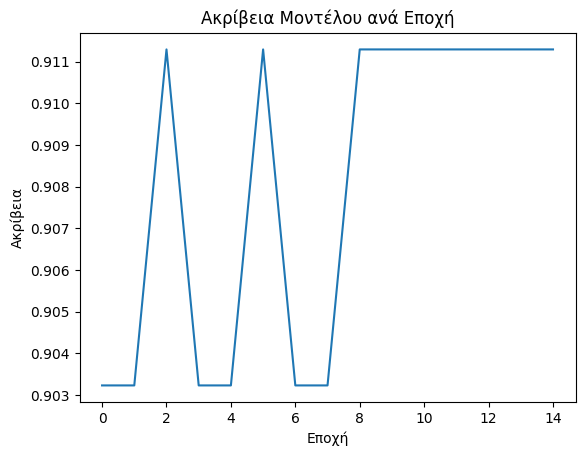

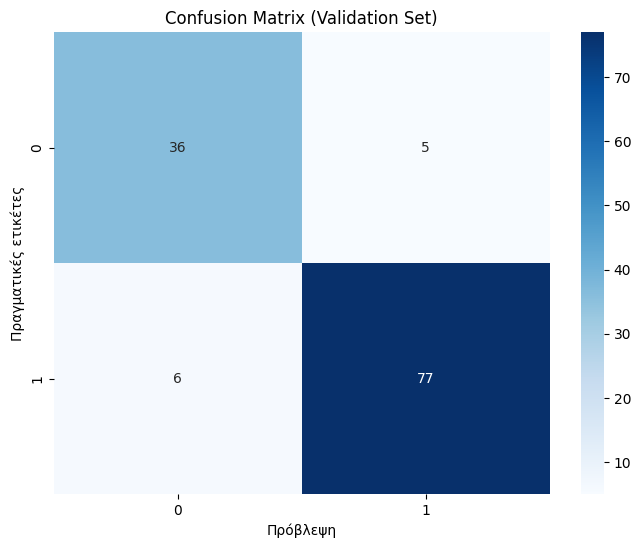

In [21]:
train_model(model_1, train_dataloader, validation_dataloader, criterion, optimizer, 15, True)

Εκπαίδευση νευρωνικού δικτύου.


Test Loss: 0.39654, Test Accuracy: 95.4545%


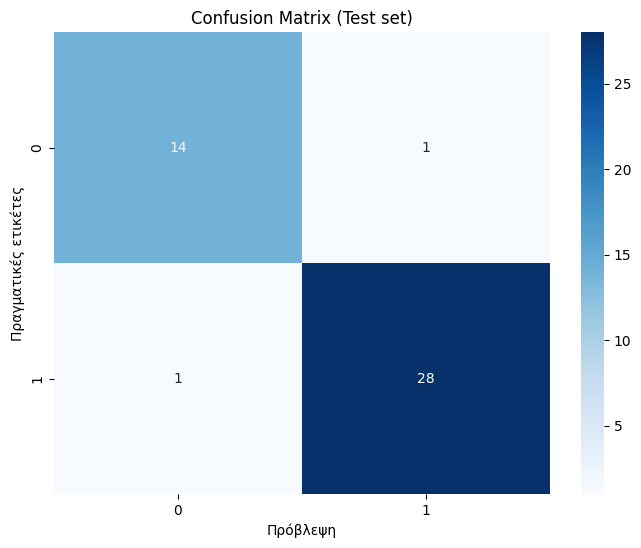

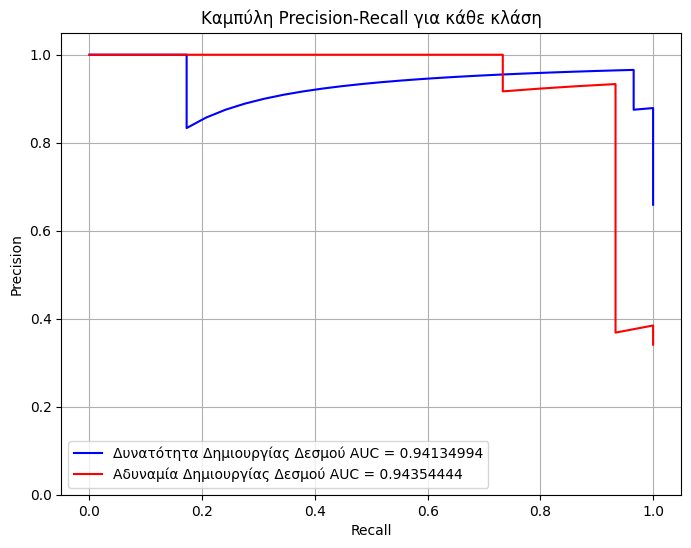

In [22]:
model_evaluation(model_1, test_dataloader, criterion, True, True)

Αξιολόγηση του μοντέλου.

# Εκτέλεση Bayesian αναζήτησης για την εύρεση καλύτερων παραμέτρων για το νευρωνικό δίκτυο.

In [23]:
# from optuna.trial import TrialState
# import torch.nn.functional as F

# class TestNeuralNetwork(nn.Module):
#     def __init__(self, trial):
#         super(TestNeuralNetwork, self).__init__()
#         # Ορίζουμε τις παραμέτρους του νευρωνικού δικτύου που θα βελτιστοποιηθούν
#         n_layers = trial.suggest_int("n_layers", 1, 3)
#         layers = []

#         in_features = data_train_lda_df.shape[1]
#         for i in range(n_layers):
#             out_features = trial.suggest_int("n_units_l{}".format(i), 4, 512, log=True)
#             layers.append(nn.Linear(in_features, out_features))
#             layers.append(nn.ReLU())
#             # Dropout
#             dropout_rate = trial.suggest_float("dropout_l{}".format(i), 0.0, 0.5)
#             layers.append(nn.Dropout(dropout_rate))
#             in_features = out_features

#         layers.append(nn.Linear(in_features, 1))
#         layers.append(nn.Sigmoid())
#         self.model = nn.Sequential(*layers)

#     def forward(self, x):
#         return self.model(x)

# def objective(trial):
#     n_epochs = trial.suggest_int("n_epochs", 5, 25)
#     n_runs = 5  # Αριθμός επαναλήψεων της εκπαίδευσης
#     total_accuracy = 0.0

#     for _ in range(n_runs):
#         model = TestNeuralNetwork(trial)
#         lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
#         optimizer = optim.Adam(model.parameters(), lr=lr)
#         criterion = nn.BCELoss()

#         # Εκπαίδευση του μοντέλου
#         for epoch in range(n_epochs):
#             model.train()
#             for batch_idx, (X, y) in enumerate(train_dataloader):
#                 optimizer.zero_grad()
#                 outputs = model(X)
#                 loss = criterion(outputs, y)
#                 loss.backward()
#                 optimizer.step()

#             # Αξιολόγηση του μοντέλου
#             model.eval()
#             correct = 0
#             total = 0
#             with torch.no_grad():
#                 for X, y in validation_dataloader:
#                     outputs = model(X)
#                     predicted = (outputs > 0.5).float()
#                     total += y.size(0)
#                     correct += (predicted == y).sum().item()

#         accuracy = correct / total
#         total_accuracy += accuracy

#         # Έλεγχος για πρόωρη διακοπή
#         if trial.should_prune():
#             raise optuna.exceptions.TrialPruned()

#     return total_accuracy / n_runs

# # Δημιουργία και εκτέλεση της Optuna study
# study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
# study.optimize(objective, n_trials=100, timeout=2000)

# # Εκτύπωση των αποτελεσμάτων
# print("Best trial:")
# trial = study.best_trial

# print(f"  Value: {trial.value}")
# print("  Params: ")
# for key, value in trial.params.items():
#     print(f"    {key}: {value}")

In [24]:
# class TestNeuralNetwork(nn.Module):
#     def __init__(self, trial):
#         super(TestNeuralNetwork, self).__init__()
#         # Ορίζουμε τις παραμέτρους του νευρωνικού δικτύου που θα βελτιστοποιηθούν
#         n_layers = 3
#         layers = []

#         in_features = data_train_lda_df.shape[1]
#         for i in range(n_layers):
#           if i == 0:
#             out_features = trial.suggest_int(f'n_units_l{i}', 150, 200)
#             layers.append(nn.Linear(in_features, out_features))
#             layers.append(nn.ReLU())
#             # Dropout
#             dropout_rate = trial.suggest_float(f'dropout_l{i}', 0.25, 0.35)
#             layers.append(nn.Dropout(dropout_rate))
#             in_features = out_features

#           elif i==1:
#             out_features = trial.suggest_int(f'n_units_l{i}', 200, 400)
#             layers.append(nn.Linear(in_features, out_features))
#             layers.append(nn.ReLU())
#             # Dropout
#             dropout_rate = trial.suggest_float(f'dropout_l{i}', 0.15, 0.35)
#             layers.append(nn.Dropout(dropout_rate))
#             in_features = out_features

#           else:
#             out_features = trial.suggest_int(f'n_units_l{i}', 30, 75)
#             layers.append(nn.Linear(in_features, out_features))
#             layers.append(nn.ReLU())
#             # Dropout
#             dropout_rate = trial.suggest_float(f'dropout_l{i}', 0.15, 0.26)
#             layers.append(nn.Dropout(dropout_rate))
#             in_features = out_features

#         layers.append(nn.Linear(in_features, 1))
#         layers.append(nn.Sigmoid())
#         self.model = nn.Sequential(*layers)

#     def forward(self, x):
#         return self.model(x)

# def objective(trial):
#     n_epochs = 10
#     n_runs = 5  # Αριθμός επαναλήψεων της εκπαίδευσης
#     total_accuracy = 0.0

#     for _ in range(n_runs):
#         model = TestNeuralNetwork(trial)
#         lr = trial.suggest_float("lr", 1e-4, 0.005, log=True)
#         optimizer = optim.Adam(model.parameters(), lr=lr)
#         criterion = nn.BCELoss()

#         # Εκπαίδευση του μοντέλου
#         for epoch in range(n_epochs):
#             model.train()
#             for batch_idx, (X, y) in enumerate(train_dataloader):
#                 optimizer.zero_grad()
#                 outputs = model(X)
#                 loss = criterion(outputs, y)
#                 loss.backward()
#                 optimizer.step()

#             # Αξιολόγηση του μοντέλου
#             model.eval()
#             correct = 0
#             total = 0
#             with torch.no_grad():
#                 for X, y in validation_dataloader:
#                     outputs = model(X)
#                     predicted = (outputs > 0.5).float()
#                     total += y.size(0)
#                     correct += (predicted == y).sum().item()

#         accuracy = correct / total
#         total_accuracy += accuracy

#         # Έλεγχος για πρόωρη διακοπή
#         if trial.should_prune():
#             raise optuna.exceptions.TrialPruned()

#     return total_accuracy / n_runs

# # Δημιουργία και εκτέλεση της Optuna study
# study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
# study.optimize(objective, n_trials=100, timeout=2000)

# # Εκτύπωση των αποτελεσμάτων
# print("Best trial:")
# trial = study.best_trial

# print(f"  Value: {trial.value}")
# print("  Params: ")
# for key, value in trial.params.items():
#     print(f"    {key}: {value}")

In [25]:
# Δημιουργία του Νευρωνικού Δικτύου
class ModifiedNeuralNetwork(nn.Module):
    def __init__(self):
        super(ModifiedNeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(data_train_lda_df.shape[1], 175)
        self.drop1 = nn.Dropout(0.32)
        self.fc2 = nn.Linear(175, 275)
        self.drop2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(275, 65)
        self.fc4 = nn.Linear(65, 1)


    def forward(self, x):
        x = self.drop1(torch.relu(self.fc1(x)))
        x = self.drop2(torch.relu(self.fc2(x)))
        x = self.drop2(torch.relu(self.fc3(x)))
        x = torch.sigmoid(self.fc4(x))
        return x

In [26]:
model_2 = ModifiedNeuralNetwork()

# Συνάρτηση Απώλειας και Βελτιστοποιητής
criterion = nn.BCELoss()
learning_rate = 0.002
optimizer = optim.Adam(model_2.parameters(), lr=learning_rate)

Ορισμός νέου μοντέλου και των παραμέτρων του.

Εποχή 1, Απώλεια: 0.2434, Ακρίβεια στο Σετ Επαλήθευσης: 89.52%
Εποχή 2, Απώλεια: 0.0633, Ακρίβεια στο Σετ Επαλήθευσης: 91.13%
Εποχή 3, Απώλεια: 0.0714, Ακρίβεια στο Σετ Επαλήθευσης: 90.32%
Εποχή 4, Απώλεια: 0.0633, Ακρίβεια στο Σετ Επαλήθευσης: 90.32%
Εποχή 5, Απώλεια: 0.0559, Ακρίβεια στο Σετ Επαλήθευσης: 90.32%
Εποχή 6, Απώλεια: 0.0529, Ακρίβεια στο Σετ Επαλήθευσης: 91.13%
Εποχή 7, Απώλεια: 0.0517, Ακρίβεια στο Σετ Επαλήθευσης: 91.13%
Εποχή 8, Απώλεια: 0.0508, Ακρίβεια στο Σετ Επαλήθευσης: 90.32%
Εποχή 9, Απώλεια: 0.0463, Ακρίβεια στο Σετ Επαλήθευσης: 91.13%
Εποχή 10, Απώλεια: 0.0471, Ακρίβεια στο Σετ Επαλήθευσης: 91.13%
Εποχή 11, Απώλεια: 0.0502, Ακρίβεια στο Σετ Επαλήθευσης: 90.32%
Εποχή 12, Απώλεια: 0.0538, Ακρίβεια στο Σετ Επαλήθευσης: 91.13%
Εποχή 13, Απώλεια: 0.0510, Ακρίβεια στο Σετ Επαλήθευσης: 91.13%
Εποχή 14, Απώλεια: 0.0502, Ακρίβεια στο Σετ Επαλήθευσης: 91.13%
Εποχή 15, Απώλεια: 0.0576, Ακρίβεια στο Σετ Επαλήθευσης: 91.13%


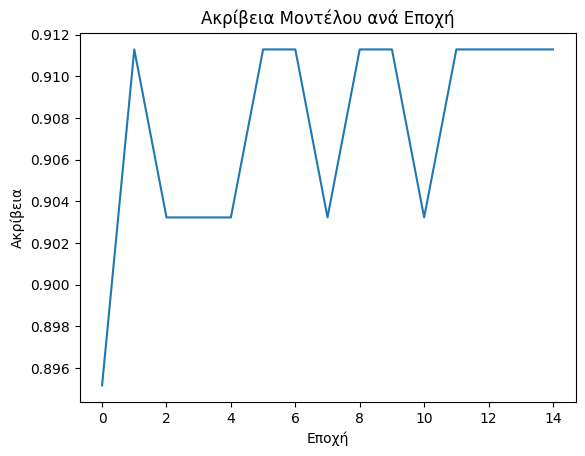

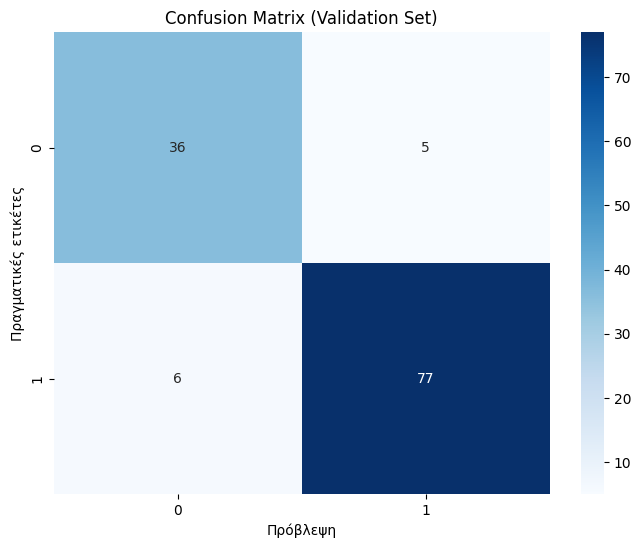

In [27]:
train_model(model_2, train_dataloader, validation_dataloader, criterion, optimizer, 15, True)


Test Loss: 2.37518, Test Accuracy: 95.4545%


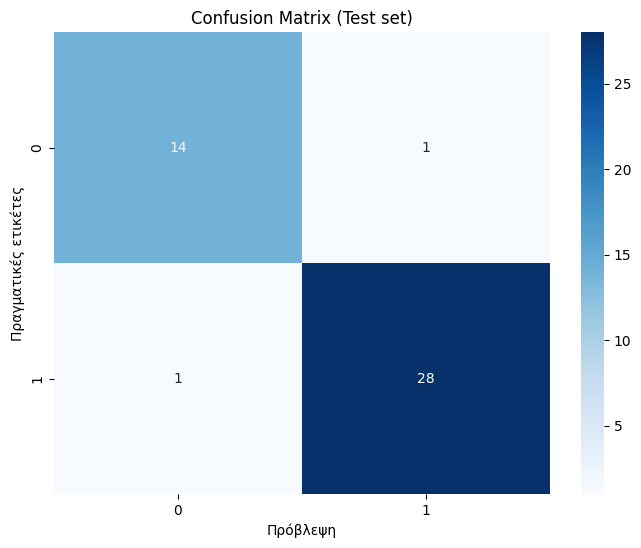

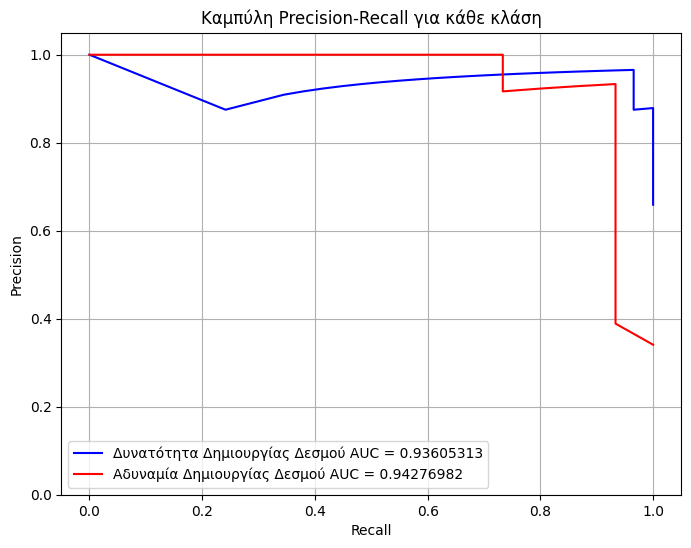

In [28]:
model_evaluation(model_2, test_dataloader, criterion, True, True)

Εκπαίδευση και αξιολόγηση του νέου μοντέλου.

# Ταξινομητής SVM

In [94]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

svm_model = SVC(probability=True)

svm_model.fit(data_train_lda_df, labels_train.values.ravel())

SVC(probability=True)

Δημιουργία ενός default SVM για πρώτη δοκιμή

In [95]:
# Πρόβλεψη στο validation set
predictions_validation = svm_model.predict(data_validation_lda_df)
accuracy_validation = accuracy_score(labels_validation, predictions_validation)
print(f'Accuracy on Validation Set: {accuracy_validation:.4f}')
print(classification_report(labels_validation, predictions_validation))

# Πρόβλεψη στο test set
predictions_test = svm_model.predict(data_test_lda_df)
accuracy_test = accuracy_score(labels_test, predictions_test)
print(f'Accuracy on Test Set: {accuracy_test:.4f}')
print(classification_report(labels_test, predictions_test))

Accuracy on Validation Set: 0.9113
              precision    recall  f1-score   support

           0       0.86      0.88      0.87        41
           1       0.94      0.93      0.93        83

    accuracy                           0.91       124
   macro avg       0.90      0.90      0.90       124
weighted avg       0.91      0.91      0.91       124

Accuracy on Test Set: 0.9545
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        15
           1       0.97      0.97      0.97        29

    accuracy                           0.95        44
   macro avg       0.95      0.95      0.95        44
weighted avg       0.95      0.95      0.95        44



Αξιολόγηση SVM ταξινομητή πάνω στα δεδομένα επαλήθευσης και δοκιμής.

In [96]:
from sklearn.model_selection import GridSearchCV

# Ορισμός των παραμέτρων για το grid search
parameters = {
    'C': [0.1, 1, 10, 100],  # Box Constraint
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'poly', 'sigmoid']  # Τύποι πυρήνων
}

svm = SVC(probability=True)

# Δημιουργία του GridSearchCV
grid_search = GridSearchCV(svm, parameters, scoring='accuracy', cv=2, verbose=2)

# Εκπαίδευση του GridSearchCV
grid_search.fit(data_train_lda_df, labels_train.values.ravel())

# Αποτελέσματα
print("Καλύτερη παράμετρος:", grid_search.best_params_)
print("Καλύτερη ακρίβεια:", grid_search.best_score_)

# Αξιολόγηση του καλύτερου μοντέλου
best_svm = grid_search.best_estimator_

predictions_validation = best_svm.predict(data_validation_lda_df).astype(float)
accuracy_validation = accuracy_score(labels_validation, predictions_validation)
print(f'Accuracy on Validation Set: {accuracy_validation:.4f}')
print(classification_report(labels_validation, predictions_validation))

predictions_test = best_svm.predict(data_test_lda_df)
accuracy_test = accuracy_score(labels_test, predictions_test)
print(f'Accuracy on Test Set: {accuracy_test:.4f}')
print(classification_report(labels_test, predictions_test))

Fitting 2 folds for each of 64 candidates, totalling 128 fits
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END ..................C=0.1, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.001, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.001, kernel=poly; total time=   0.0s
[CV] END .................C=0.1, gamma=0.001, kernel=sigmoid; total time=   0.0s
[CV] END .................C=0.1, gamma=0.001, kernel=sigmoid; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ...................C=0.1, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END ...................C=0.1, gamma=0.01, 

Εκτέλεση GridSearch για την εύρεση των καλύτερων δυνατών παραμέτρων για την δημιουργία και την εκπαίδευση του SVM πάνω στα δεδομένα εκπαίδευσης.

In [97]:
#SVM μοντέλο που βρέθηκε με καλά χαρακτηριστικά
# svm_model = SVC(C=0.1, kernel='linear', gamma=0.001, probability=True)
svm_model = SVC(C=0.1, kernel='linear', probability=True)

svm_model.fit(data_train_lda_df, labels_train.values.ravel())

# Πρόβλεψη στο validation set
predictions_validation = svm_model.predict(data_validation_lda_df)
accuracy_validation = accuracy_score(labels_validation, predictions_validation)
print(f'Accuracy on Validation Set: {accuracy_validation:.4f}')
print(classification_report(labels_validation, predictions_validation))

# Πρόβλεψη στο test set
predictions_test = svm_model.predict(data_test_lda_df)
accuracy_test = accuracy_score(labels_test, predictions_test)
print(f'Accuracy on Test Set: {accuracy_test:.4f}')
print(classification_report(labels_test, predictions_test))

Accuracy on Validation Set: 0.9113
              precision    recall  f1-score   support

           0       0.86      0.88      0.87        41
           1       0.94      0.93      0.93        83

    accuracy                           0.91       124
   macro avg       0.90      0.90      0.90       124
weighted avg       0.91      0.91      0.91       124

Accuracy on Test Set: 0.9545
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        15
           1       0.97      0.97      0.97        29

    accuracy                           0.95        44
   macro avg       0.95      0.95      0.95        44
weighted avg       0.95      0.95      0.95        44



Αξιολόγηση του τελικού SVM ταξινομητή πάνω στα δεδομένα επαλήθευσης και δοκιμής.

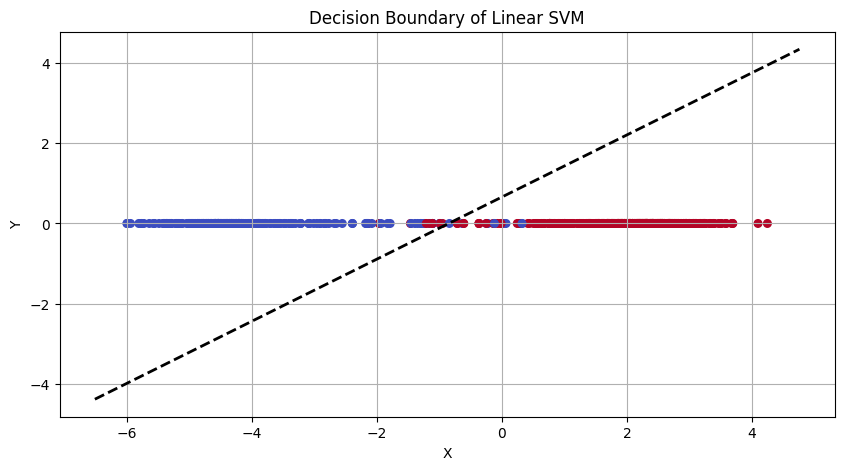

In [134]:
# Σχεδίαση του διαχωριστικού επιπέδου
plt.figure(figsize=(10, 5))
plt.scatter(data_train_lda_df, [0]*len(labels_train.values.ravel()), c=labels_train.values.ravel(), cmap='coolwarm', s=30)

ax = plt.gca()
xlim = ax.get_xlim()
xx = np.linspace(xlim[0], xlim[1], 100)
yy = svm_model.decision_function(xx.reshape(-1, 1))


plt.plot(xx, yy, color='k', linestyle='--', linewidth=2)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Decision Boundary of Linear SVM')
plt.grid(True)
plt.show()

Δημιουγία απεικόνισης για τον διαχωρισμό που κάνει ο εκπαιδευμένος SVM ταξινομητής στα δεδομένα εκπαίδευσης.

#Δοκιμές για εκπαίδευση του SVM στα δεδομένα πριν την LDA, και μετά την LDA, αλλά προσθετοντας 2η στήλη με τα χαρακτηριστικά της πρώτης στο τετράγωνο.

In [98]:
#SVM μοντέλο που βρέθηκε με καλά χαρακτηριστικά
# svm_model = SVC(C=0.1, kernel='linear', gamma=0.001, probability=True)
svm_model_pca = SVC(C=0.1, kernel='linear', probability=True)

svm_model_pca.fit(data_train_pca_426, labels_train.values.ravel())

# Πρόβλεψη στο validation set
predictions_validation = svm_model_pca.predict(data_validation_pca_426)
accuracy_validation = accuracy_score(labels_validation, predictions_validation)
print(f'Accuracy on Validation Set: {accuracy_validation:.4f}')
print(classification_report(labels_validation, predictions_validation))

# Πρόβλεψη στο test set
predictions_test = svm_model_pca.predict(data_test_pca_426)
accuracy_test = accuracy_score(labels_test, predictions_test)
print(f'Accuracy on Test Set: {accuracy_test:.4f}')
print(classification_report(labels_test, predictions_test))

Accuracy on Validation Set: 0.8548
              precision    recall  f1-score   support

           0       0.78      0.78      0.78        41
           1       0.89      0.89      0.89        83

    accuracy                           0.85       124
   macro avg       0.84      0.84      0.84       124
weighted avg       0.85      0.85      0.85       124

Accuracy on Test Set: 0.8864
              precision    recall  f1-score   support

           0       0.92      0.73      0.81        15
           1       0.88      0.97      0.92        29

    accuracy                           0.89        44
   macro avg       0.90      0.85      0.87        44
weighted avg       0.89      0.89      0.88        44



Ο SVM δοκιμάστηκε και στον χώρο που ορίζει η PCA για 426 κύριες συνιστώσες, αλλά όπως φαίνεται τα αποτελέσματα δεν είναι αρκετά καλά.

In [99]:
new_train = data_train_lda_df.copy()
new_train[1] = new_train[0]**2

new_validation = data_validation_lda_df.copy()
new_validation[1] = new_validation[0]**2

# Ορισμός των παραμέτρων για το grid search
parameters = {
    'C': [0.1, 1, 10, 100],  # Box Constraint
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'poly', 'sigmoid']  # Τύποι πυρήνων
}

svm = SVC(probability=True)

# Δημιουργία του GridSearchCV
grid_search = GridSearchCV(svm, parameters, scoring='accuracy', cv=2, verbose=2)

# Εκπαίδευση του GridSearchCV
grid_search.fit(new_train, labels_train.values.ravel())

# Αποτελέσματα
print("Καλύτερη παράμετρος:", grid_search.best_params_)
print("Καλύτερη ακρίβεια:", grid_search.best_score_)

# Αξιολόγηση του καλύτερου μοντέλου
best_svm = grid_search.best_estimator_

predictions_validation = best_svm.predict(new_validation).astype(float)
accuracy_validation = accuracy_score(labels_validation, predictions_validation)
print(f'Accuracy on Validation Set: {accuracy_validation:.4f}')
print(classification_report(labels_validation, predictions_validation))

Fitting 2 folds for each of 64 candidates, totalling 128 fits
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END ..................C=0.1, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=0.001, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.001, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.001, kernel=poly; total time=   0.0s
[CV] END .................C=0.1, gamma=0.001, kernel=sigmoid; total time=   0.0s
[CV] END .................C=0.1, gamma=0.001, kernel=sigmoid; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ...................C=0.1, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END ...................C=0.1, gamma=0.01, 

In [100]:
new_test = data_test_lda_df.copy()
new_test[1] = new_test[0]**2

predictions_test = best_svm.predict(new_test).astype(float)
accuracy_test = accuracy_score(labels_test, predictions_test)
print(f'Accuracy on Validation Set: {accuracy_test:.4f}')
print(classification_report(labels_test, predictions_test))

Accuracy on Validation Set: 0.9545
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        15
           1       0.97      0.97      0.97        29

    accuracy                           0.95        44
   macro avg       0.95      0.95      0.95        44
weighted avg       0.95      0.95      0.95        44



Όπως φαίνεται σε καμία από τις νέες περιπτώσεις δεν βελτιώνει την απόδοση του SVM, άρα θα παραμείνουμε στην αρχική εκδοχή του SVM.
Δηλαδή στα δεδομένα αφού έχουν Κανονικοποιηθεί, εφαρμοστεί σε PCA και σε LDA.

# Ensemble Method (Model_2 και SVM ταξινομητής)

In [101]:
def most_confident_predictions(model_nn, model_svm, X):
    # Προετοιμασία δεδομένων για το νευρωνικό δίκτυο
    X_nn = torch.tensor(X.values).float()
    with torch.no_grad():
        nn_outputs = model_nn(X_nn)
    nn_probabilities = torch.sigmoid(nn_outputs).numpy().flatten()

    # Πιθανότητες από τον SVM
    svm_probabilities = model_svm.predict_proba(X)[:, 1]

    # Επιλογή της απόφασης του "πιο σίγουρου" μοντέλου
    final_predictions = []
    for nn_prob, svm_prob in zip(nn_probabilities, svm_probabilities):
        if max(nn_prob, 1 - nn_prob) >= max(svm_prob, 1 - svm_prob):
            # Το νευρωνικό δίκτυο είναι πιο σίγουρο
            prediction = 1.0 if nn_prob > 0.5 else 0.0
        else:
            # Ο SVM είναι πιο σίγουρος
            prediction = 1.0 if svm_prob > 0.5 else 0.0
        final_predictions.append(prediction)

    return final_predictions

Δημιουργία συνάρτηση η οποία παίρνει ως παραμέτρους ένα νευρωνικό μοντέλο, ένα ταξινομητή SVM και ένα σύνολο δεδομένων για να τα ταξινομήσουν και οι δύο ταξινομητές.

Από τις δύο ταξινομήσεις κρατάμε τα prediction scores του καθενός. Τα prediction scores στην ουσία είναι η σιγουριά με την οποία ταξινομούν τα δύο συστήματα ένα δεδομένα.

Επειδή κάνουν δυαδική ταξινόμηση οι πιθανότητες που υπολογίζουν είναι από το 0 έως το 1. Αν η πιθανότητα που υπολογίζεται είναι μεγαλύτερη του 0.5, τότε το δεδομένο ταξινομείται στην κλάση 1, σε αντίθεση περίπτωση ταξινομείται στην κλάση 0.

Η σιγουριά για κάθε ταξινόμηση υπολογίζεται από την απόσταση κάθε πιθανότητας που υπολογίζεται από το μέσο 0.5.

Πριν το τέλος διατηρεί την πρόβλεψη του πιο σίγουρου μοντέλου, δηλαδή αυτού που η πιθανότητα είναι πιο μακριά από το 0.5.

Στο τέλος η συνάρτηση επιστρέφει τις τελικές προβλέψεις.

In [102]:
# Αξιολόγηση στο validation set
most_confident_predictions_val = most_confident_predictions(model_2, svm_model, data_validation_lda_df)
accuracy_val = accuracy_score(labels_validation, most_confident_predictions_val)
print(f'Accuracy on Validation Set: {accuracy_val:.4f}')

# Αξιολόγηση στο test set
most_confident_predictions_test = most_confident_predictions(model_2, svm_model, data_test_lda_df)
accuracy_test = accuracy_score(labels_test, most_confident_predictions_test)
print(f'Accuracy on Test Set: {accuracy_test:.4f}')


Accuracy on Validation Set: 0.9113
Accuracy on Test Set: 0.9318


Εφαρμογή του συνδιαστικού μοντέλου στα δεδομένα επαλήθευσης και στα δεδομένα δοκιμής.

In [103]:
model_2.eval()
all_predictions = []

with torch.no_grad():
    for data, labels in validation_dataloader:
        outputs = model_2(data)
        predicted = (outputs > 0.5).float()

        all_predictions.extend(predicted.cpu().numpy().flatten())


model_2.eval()
all_predictions_test = []

with torch.no_grad():
    for data, labels in test_dataloader:
        outputs = model_2(data)
        predicted = (outputs > 0.5).float()

        all_predictions_test.extend(predicted.cpu().numpy().flatten())

Εφαρμόζονται στο νευρωνικό μοντέλο και πάλι τα δεδομένα του σετ επαλήθευσης και κρατάμε τις προβλέψεις σε μία λίστα.

In [104]:
def compare_lists(list1, list2, list3):
    # Σύγκριση λίστας 1 με λίστα 2
    diff_1_2 = sum([1 for x, y in zip(list1, list2) if x != y])

    # Σύγκριση λίστας 1 με λίστα 3
    diff_1_3 = sum([1 for x, y in zip(list1, list3) if x != y])

    # Σύγκριση λίστας 2 με λίστα 3
    diff_2_3 = sum([1 for x, y in zip(list2, list3) if x != y])

    return diff_1_2, diff_1_3, diff_2_3


differences = compare_lists(np.array(all_predictions), predictions_validation, np.array(most_confident_predictions_val))
print(f'Διαφορές μεταξύ λίστας 1 και λίστας 2: {differences[0]}')
print(f'Διαφορές μεταξύ λίστας 1 και λίστας 3: {differences[1]}')
print(f'Διαφορές μεταξύ λίστας 2 και λίστας 3: {differences[2]}')


Διαφορές μεταξύ λίστας 1 και λίστας 2: 0
Διαφορές μεταξύ λίστας 1 και λίστας 3: 0
Διαφορές μεταξύ λίστας 2 και λίστας 3: 0


Κώδικας για την σύγκριση των προβλέψεων των μοντέλων στο σετ επαλήθευσης. Απλά για να δούμε πως διαφέρουν τα αποτελέσματα μεταξύ του.

In [105]:
differences = compare_lists(np.array(all_predictions_test), predictions_test, np.array(most_confident_predictions_test))
print(f'Διαφορές μεταξύ λίστας 1 και λίστας 2: {differences[0]}')
print(f'Διαφορές μεταξύ λίστας 1 και λίστας 3: {differences[1]}')
print(f'Διαφορές μεταξύ λίστας 2 και λίστας 3: {differences[2]}')

Διαφορές μεταξύ λίστας 1 και λίστας 2: 0
Διαφορές μεταξύ λίστας 1 και λίστας 3: 1
Διαφορές μεταξύ λίστας 2 και λίστας 3: 1


# **Ερώτημα C**

**Δώστε την εκτίμησή σας για το σφάλμα που θα έχει το εκπαιδευμένο μοντέλο σας στο test set, δεδομένου ότι η κατανομή κλάσεων στο test set είναι παρόμοια με αυτή των δεδομένων εκπαίδευσης. Να εκτιμήσετε επίσης το AUC για την καμπύλη TP-FP. Τέλος, να παράξετε ένα αρχείο με όνομα test_predictions.csv στο οποίο θα καταχωρήσετε την πρόβλεψη του μοντέλου σας για κάθε δείγμα από το test set στη μορφή predicted_label,prediction_score σε κάθε γραμμή, με τη σειρά που περιέχονται τα δεδομένα στο test_features.csv. Το prediction_score αποτελεί την πρωτογενή έξοδο του ταξινομητή σας και πρέπει να είναι είτε η πιθανότητα πρόσδεσης είτε να έχει αύξουσα τιμή για αυξανόμενη πιθανότητα πρόσδεσης. Το αρχείο να συμπεριληφθεί μαζί με τα υπόλοιπα παραδοτέα της εργασίας στην υποβολή σας**

In [106]:
def most_confident_predictions_with_probabilities(model_nn, model_svm, X):
    # Προετοιμασία δεδομένων για το νευρωνικό δίκτυο
    X_nn = torch.tensor(X.values).float()
    with torch.no_grad():
        nn_outputs = model_nn(X_nn)
    nn_probabilities = torch.sigmoid(nn_outputs).numpy().flatten()

    # Πιθανότητες από τον SVM
    svm_probabilities = model_svm.predict_proba(X)[:, 1]

    # Επιλογή της απόφασης του "πιο σίγουρου" μοντέλου
    final_predictions = []
    final_probabilities = []

    for nn_prob, svm_prob in zip(nn_probabilities, svm_probabilities):
        if max(nn_prob, 1 - nn_prob) > max(svm_prob, 1 - svm_prob):
            # Το νευρωνικό δίκτυο είναι πιο σίγουρο
            prediction = 1.0 if nn_prob > 0.5 else 0.0
            final_probabilities.append(nn_prob)
        else:
            # Ο SVM είναι πιο σίγουρος
            prediction = 1.0 if svm_prob > 0.5 else 0.0
            final_probabilities.append(svm_prob)

        final_predictions.append(prediction)

    return final_predictions, final_probabilities

Συνάρτηση που κάνει συνδιαστική πρόβλεψη κρατώντας αυτή του πιο σίγουρου μοντέλου, αλλά σε αυτη την περίπτωση επιστρέφει και τα accuracy_scores.

In [107]:
from sklearn.metrics import roc_curve, auc

def evaluate_with_tp_fp_curve(probabilities, true_labels):
    # Υπολογισμός καμπύλης TP-FP (ROC curve)
    fpr, tpr, _ = roc_curve(true_labels, probabilities, pos_label=1)
    auc_score_tp_fp = auc(fpr, tpr)

    # Απεικόνιση καμπύλης TP-FP
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'TP-FP Curve (AUC = {auc_score_tp_fp:.8f})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('TP-FP Curve')
    plt.legend(loc='best')
    plt.grid(True)
    plt.ylim([0, 1.05])
    plt.xlim([0, 1.0])
    plt.show()

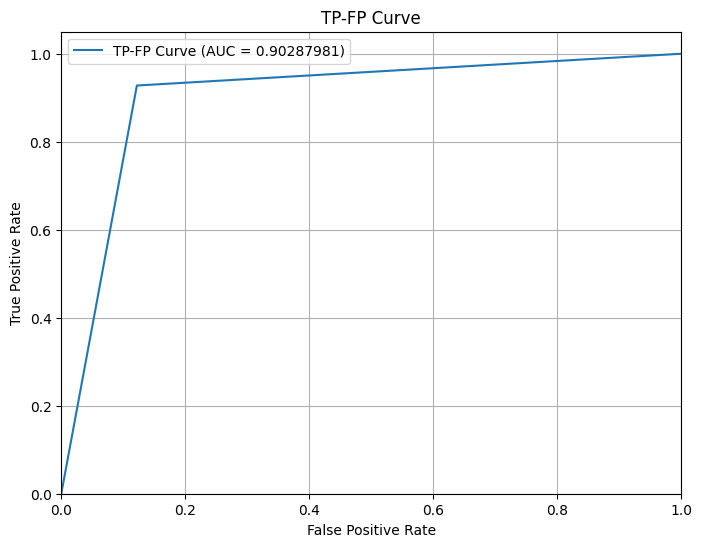

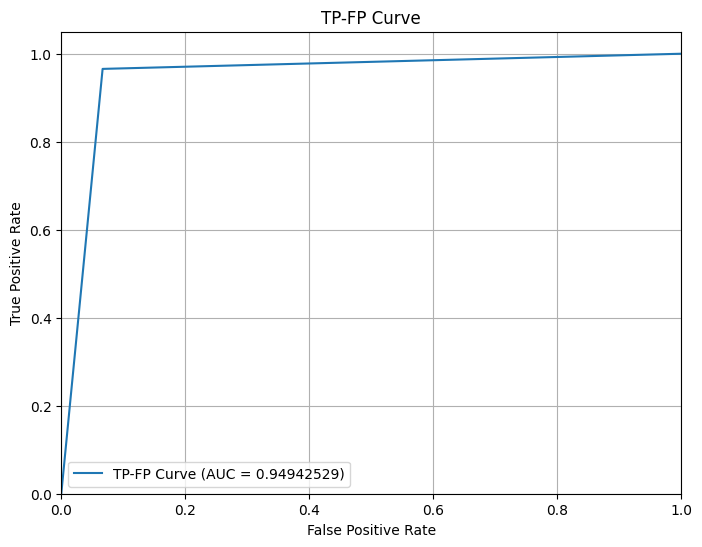

In [108]:
evaluate_with_tp_fp_curve(all_predictions, labels_validation)
print()
evaluate_with_tp_fp_curve(all_predictions_test, labels_test)

Καμπύλη TP-FP στα σετ επαλήθευσης και δοκιμής για το μοντέλο νευρωνικού δικτύου που εκπαιδεύτηκε.

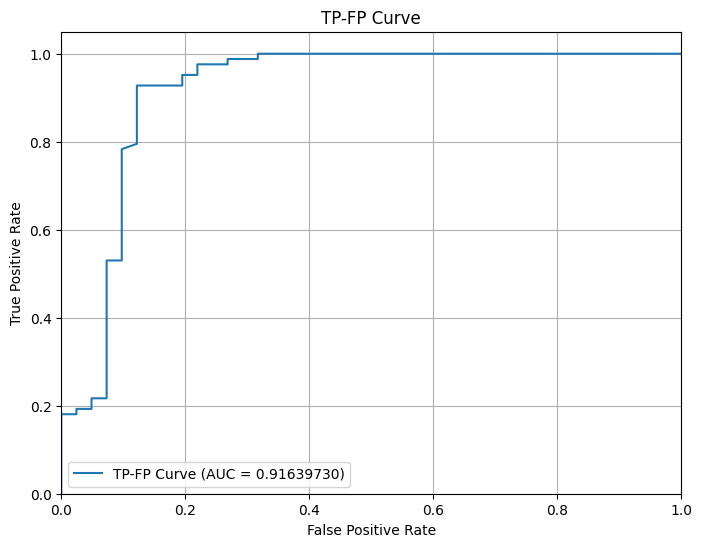

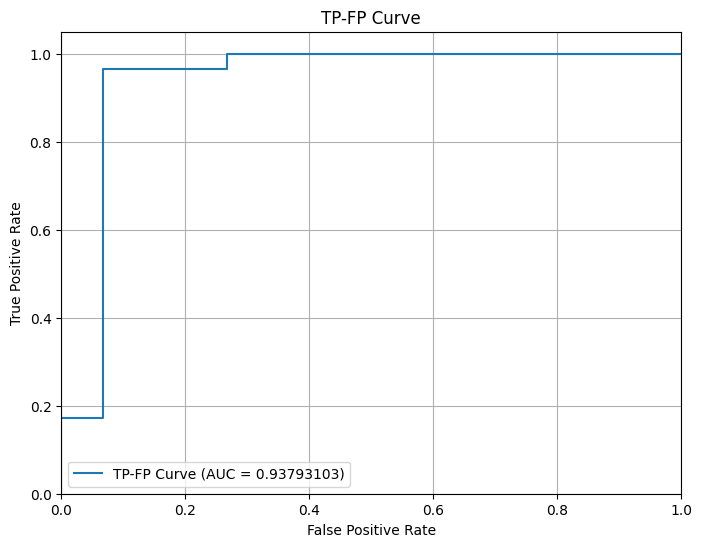

In [109]:
svm_probabilities_val = svm_model.predict_proba(data_validation_lda_df)[:, 1]
svm_probabilities_test = svm_model.predict_proba(data_test_lda_df)[:, 1]

evaluate_with_tp_fp_curve(svm_probabilities_val, labels_validation)
print()
evaluate_with_tp_fp_curve(svm_probabilities_test, labels_test)

Καμπύλη TP-FP στα σετ επαλήθευσης και δοκιμής για τον ταξινομητή SVM.

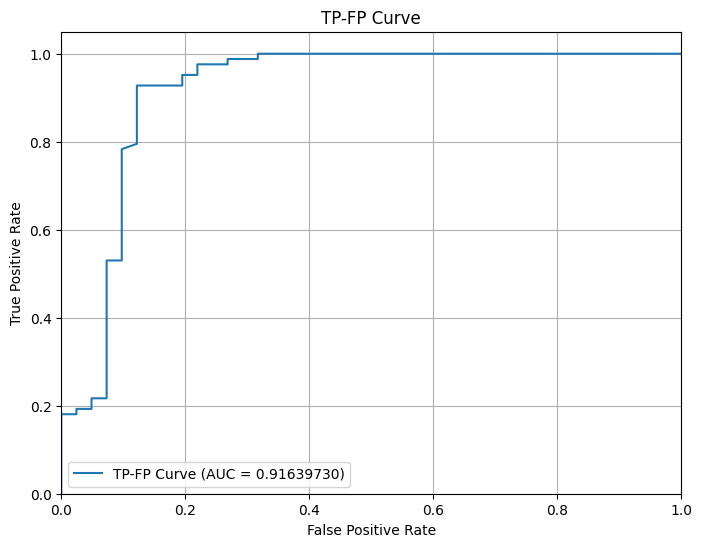

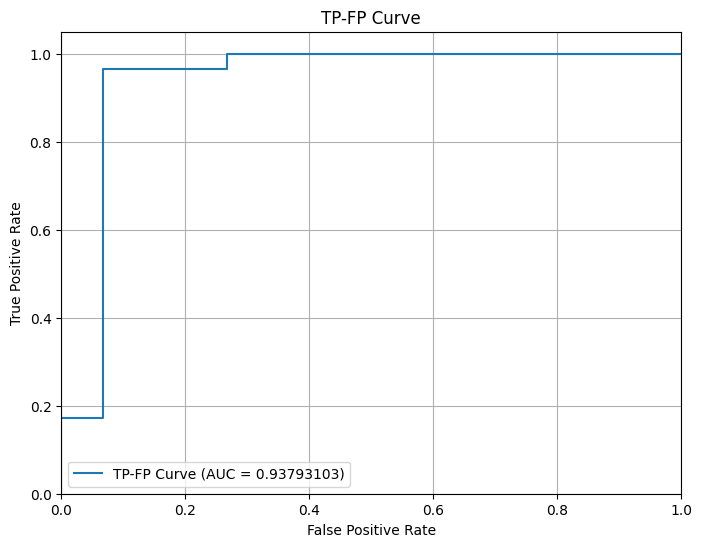

In [110]:
_, combined_probabilities_val = most_confident_predictions_with_probabilities(model_2, svm_model, data_validation_lda_df)
_, combined_probabilities_test = most_confident_predictions_with_probabilities(model_2, svm_model, data_test_lda_df)

evaluate_with_tp_fp_curve(combined_probabilities_val, labels_validation)
print()
evaluate_with_tp_fp_curve(combined_probabilities_test, labels_test)

Καμπύλη TP-FP στα σετ επαλήθευσης και δοκιμής για το συνδιαστικό μοντέλο του νευρωνικού δικτύου που εκπαιδεύτηκε και του SVM ταξινομητή.

# Εξαγωγή σε προβλέψεων csv αρχείο

Για να κάνω πρόβλεψη για τα unlabeled δεδομένα πρέπει πρώτα να τα μεταφέρω στους ανάλογους χώρους:

1. Κανονικοποίηση
2. Χώρος των 426 κύριων συνιστωσών
3. Χώρο που ορίζει η LDA

In [111]:
normalized_unlabeled = scaler.transform(unlabeled_test_data) # Κανονικοποίηση

unlabeled_pca = pca_426.transform(normalized_unlabeled) # PCA
unlabeled_pca = pd.DataFrame(unlabeled_pca)

unlabeled_lda = lda.transform(unlabeled_pca) # LDA
unlabeled_lda = pd.DataFrame(unlabeled_lda)

Αποφάσισα, αν και δεν υπάρχει μεγάλη διαφορά για την πρόβλεψη να χρησιμοποιήσω την ensemble μέθοδο που συνδιάζει τα αποτελέσματα του model_2 και του SVM κρατώντας την πρόβλεψη του πιο confident μοντέλου κάθε φορά.
Η επιλογή έγινε γιατί η συγκεκριμένη μέθοδος φάνηκε να έχει καλύτερα αποτελέσματα σταθερα, ενώ οι υπόλοιπες έτειναν να έυχουν κάποιες αυξομειώσεις.

In [112]:
# Συνδυασμός των προβλέψεων με max voting
ensemble_probabilities_unlabeled = []
ensemble_prediction_unlabeled = []

project_preditions, project_prediction_scores = most_confident_predictions_with_probabilities(model_2, svm_model, unlabeled_lda)

In [113]:
print(project_preditions)
print(project_prediction_scores)

[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.372340934909453, 0.002983588980490922, 0.9999984930155297, 0.0007459277056642082, 0.0006525119835906123, 0.3060662307515378, 0.0017876134780603495, 0.0002933060268470834, 0.0007557169444681357, 0.9999844596242741, 0.64722157, 0.000170059757928769, 0.9999992773720198, 0.4120993844693438, 0.9971692223101565, 0.9546625495896284, 0.9999957241330328, 0.64580935, 0.99998307046874

In [114]:
# Δημιουργία κώδικα για εξαγωγή δύο λιστών σε αρχείο CSV
def export_to_csv(list1, list2, filename):
    import pandas as pd

    # Δημιουργία DataFrame από τις λίστες
    df = pd.DataFrame({'List1': list1, 'List2': list2})

    # Εξαγωγή DataFrame σε αρχείο CSV
    df.to_csv(filename, index=False, header=None)

# Κλήση της συνάρτησης για εξαγωγή σε CSV
export_to_csv(project_preditions, project_prediction_scores, 'test_predictions.csv')

#**ΑΠΟ ΕΔΩ ΚΑΙ ΚΑΤΩ ΕΙΝΑΙ ΠΡΑΓΜΑΤΑ ΕΚΤΟΣ ΑΝΑΦΟΡΑΣ**

Αυτό το μέρος της εργασίας δεν πρόλαβα να το προσθέσω στην αναφορά.

Πέρα από την έλλειψη χρόνου στο τέλος δεν έπαιξε ρόλο στα αποτελέσματα, οπότε δεν πειραζε να μείναι εκτός. Επειδή όμως υλοποιήθηκε και αφιερώθηκε χρόνος το άφησα μέσα στο παραδοτέο Notebook

**Μπορείτε να το αγνοείσετε τελείως και να μην το λάβετε υπόψη για την βαθμολογία της εργασίας.**

# Ταξινομητής Random Forest

In [115]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.decomposition import PCA


# Δημιουργία και εκπαίδευση του μοντέλου Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=123)
rf_model.fit(data_train_pca_426, labels_train.values.ravel())

RandomForestClassifier(max_depth=10, random_state=123)

In [116]:
# Πρόβλεψη στο σετ επαλήθευσης
labels_pred_val = rf_model.predict(data_validation_pca_426)

# Αξιολόγηση του μοντέλου
accuracy_val = accuracy_score(labels_validation, labels_pred_val)
report_val = classification_report(labels_validation, labels_pred_val)

# Πρόβλεψη στο σετ δοκιμής
labels_pred_test = rf_model.predict(data_test_pca_426)

# Αξιολόγηση του μοντέλου
accuracy_test = accuracy_score(labels_test, labels_pred_test)
report_test = classification_report(labels_test, labels_pred_test)

print(accuracy_val)
print(report_val)

print(accuracy_test)
print(report_test)

0.9032258064516129
              precision    recall  f1-score   support

           0       0.97      0.73      0.83        41
           1       0.88      0.99      0.93        83

    accuracy                           0.90       124
   macro avg       0.92      0.86      0.88       124
weighted avg       0.91      0.90      0.90       124

0.8863636363636364
              precision    recall  f1-score   support

           0       1.00      0.67      0.80        15
           1       0.85      1.00      0.92        29

    accuracy                           0.89        44
   macro avg       0.93      0.83      0.86        44
weighted avg       0.90      0.89      0.88        44



#Averaging Ensemble Μέθοδος (Model_2 και Random Forest Ταξινομητής)

In [117]:
# Υπολογισμός πιθανοτήτων πρόσδεσης από το νευρωνικό δίκτυο για το σετ επαλήθευσης
model_2.eval()
nn_probabilities_val = []
nn_probabilities_test = []
nn_predictions_val = []
nn_predictions_test = []

with torch.no_grad():
    for data, labels in validation_dataloader:
        outputs = model_2(data)
        probability = outputs.squeeze()
        predicted = (outputs > 0.5).float()

        nn_predictions_val.extend(predicted.cpu().numpy().flatten())
        nn_probabilities_val.extend(probability.cpu().numpy())

with torch.no_grad():
  for data, labels in test_dataloader:
        outputs = model_2(data)
        probability = outputs.squeeze()
        predicted = (outputs > 0.5).float()

        nn_predictions_test.extend(predicted.cpu().numpy().flatten())
        nn_probabilities_test.extend(probability.cpu().numpy())

# Υπολογισμός πιθανοτήτων πρόσδεσης από το μοντέλο Random Forest για το σετ επαλήθευσης
rf_probabilities_val = rf_model.predict_proba(data_validation_pca_426)[:, 1]
rf_probabilities_test = rf_model.predict_proba(data_test_pca_426)[:, 1]

# Συνδυασμός των προβλέψεων: Μέσος όρος των πιθανοτήτων από τα δύο μοντέλα
ensemble_predictions_val = (nn_probabilities_val + rf_probabilities_val) / 2
ensemble_predictions_test = (nn_probabilities_test + rf_probabilities_test) / 2

# Απόφαση πρόσδεσης ή μη βάσει του μέσου όρου των πιθανοτήτων (κατώφλι 0.5)
ensemble_predicted_labels_val = (ensemble_predictions_val > 0.5).astype(int)
ensemble_predicted_labels_test = (ensemble_predictions_test > 0.5).astype(int)

# Αξιολόγηση του συνδυασμένου μοντέλου
ensemble_accuracy_val = accuracy_score(labels_validation, ensemble_predicted_labels_val)
ensemble_report_val = classification_report(labels_validation, ensemble_predicted_labels_val)
ensemble_accuracy_test = accuracy_score(labels_test, ensemble_predicted_labels_test)
ensemble_report_test = classification_report(labels_test, ensemble_predicted_labels_test)


print(ensemble_accuracy_val)
print(ensemble_report_val)
print('==========================================')
print(ensemble_accuracy_test)
print(ensemble_report_test)

0.9032258064516129
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        41
           1       0.93      0.93      0.93        83

    accuracy                           0.90       124
   macro avg       0.89      0.89      0.89       124
weighted avg       0.90      0.90      0.90       124

0.9090909090909091
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        15
           1       0.90      0.97      0.93        29

    accuracy                           0.91        44
   macro avg       0.91      0.88      0.90        44
weighted avg       0.91      0.91      0.91        44



# Most Confident Ensemble Μεθοδος (Model_2 και Random Forest)

In [118]:
# Συνδυασμός των προβλέψεων με max voting
ensemble_predicted_labels_val = []
ensemble_predicted_labels_test = []

for nn_prob, rf_prob in zip(nn_probabilities_val, rf_probabilities_val):
    # Υπολογισμός εμπιστοσύνης (απόσταση από 0.5)
    nn_confidence = abs(nn_prob - 0.5)
    rf_confidence = abs(rf_prob - 0.5)

    # Επιλογή ετικέτας από το πιο confident μοντέλο
    if nn_confidence > rf_confidence:
        ensemble_predicted_labels_val.append(int(nn_prob > 0.5))
    else:
        ensemble_predicted_labels_val.append(int(rf_prob > 0.5))


for nn_prob, rf_prob in zip(nn_probabilities_test, rf_probabilities_test):
    # Υπολογισμός εμπιστοσύνης (απόσταση από 0.5)
    nn_confidence = abs(nn_prob - 0.5)
    rf_confidence = abs(rf_prob - 0.5)

    # Επιλογή ετικέτας από το πιο confident μοντέλο
    if nn_confidence > rf_confidence:
        ensemble_predicted_labels_test.append(int(nn_prob > 0.5))
    else:
        ensemble_predicted_labels_test.append(int(rf_prob > 0.5))

# Αξιολόγηση του συνδυασμένου μοντέλου
ensemble_accuracy_val = accuracy_score(labels_validation, ensemble_predicted_labels_val)
ensemble_report_val = classification_report(labels_validation, ensemble_predicted_labels_val)

print(ensemble_accuracy_val)
print(ensemble_report_val)
print('=============================')
print(ensemble_accuracy_test)
print(ensemble_report_test)

0.9032258064516129
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        41
           1       0.93      0.93      0.93        83

    accuracy                           0.90       124
   macro avg       0.89      0.89      0.89       124
weighted avg       0.90      0.90      0.90       124

0.9090909090909091
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        15
           1       0.90      0.97      0.93        29

    accuracy                           0.91        44
   macro avg       0.91      0.88      0.90        44
weighted avg       0.91      0.91      0.91        44



In [119]:
differences = compare_lists(np.array(nn_predictions_val), np.array(ensemble_predicted_labels_val), np.array(most_confident_predictions_val))
print(f'Διαφορές μεταξύ λίστας 1 και λίστας 2: {differences[0]}')
print(f'Διαφορές μεταξύ λίστας 1 και λίστας 3: {differences[1]}')
print(f'Διαφορές μεταξύ λίστας 2 και λίστας 3: {differences[2]}')

Διαφορές μεταξύ λίστας 1 και λίστας 2: 1
Διαφορές μεταξύ λίστας 1 και λίστας 3: 0
Διαφορές μεταξύ λίστας 2 και λίστας 3: 1
